In [1]:
!pip install -r ../requirements.txt

In [ ]:
import os
import re
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import matplotlib.pyplot as plt


In [3]:
DATA_FOLDER = "../data/raw/" 

def load_documents(folder_path):
    documents = []
    
    if not os.path.exists(folder_path):
        print(f"⚠️  Folder '{folder_path}' not found. Please create it and add your PDFs.")
        return documents
    
    pdf_files = [f for f in os.listdir(folder_path) if f.endswith(".pdf")]
    
    if not pdf_files:
        print("⚠️  No PDF files found in the folder.")
        return documents
    
    for filename in pdf_files:
        filepath = os.path.join(folder_path, filename)
        try:
            loader = PyPDFLoader(filepath)
            docs = loader.load()
            documents.extend(docs)
            print(f"✅ Loaded: {filename:<50} | Pages: {len(docs)}")
        except Exception as e:
            print(f"❌ Failed to load {filename}: {e}")
    
    return documents

documents = load_documents(DATA_FOLDER)
print(f"\n📚 Total pages loaded: {len(documents)}")


✅ Loaded: Increasing_Anaerobic_Endurance_Using_Strength_Endu.pdf | Pages: 12
✅ Loaded: NSCA_1.pdf                                         | Pages: 24
✅ Loaded: NSCA_2.pdf                                         | Pages: 28
✅ Loaded: NSCA_3.pdf                                         | Pages: 34
✅ Loaded: NSCA_4.pdf                                         | Pages: 19
✅ Loaded: NSCA_5.pdf                                         | Pages: 20
✅ Loaded: ProgressiveOverloadinLong-TermExerciseInterventionsTargetingExecutiveFunction.pdf | Pages: 52
✅ Loaded: progressive_overload.pdf                           | Pages: 7
✅ Loaded: SSW.pdf                                            | Pages: 5
✅ Loaded: WHO.pdf                                            | Pages: 104

📚 Total pages loaded: 305


In [4]:
# Preview the first loaded page
if documents:
    sample = documents[13]
    print(f"Source : {sample.metadata.get('source', 'Unknown')}")
    print(f"Page   : {sample.metadata.get('page', 'Unknown')}")
    print(f"\n--- Raw Text Preview (first 800 chars) ---\n")
    print(sample.page_content[:-1])
else:
    print("No documents loaded yet.")

Source : ../data/raw/NSCA_1.pdf
Page   : 1

--- Raw Text Preview (first 800 chars) ---

this information are encouraged to
seek and obtain such advice, if needed
or desired, from those licensed
professionals.
INTRODUCTION
SCOPE OF PRACTICE
The legal responsibilities and profes-
sional scope of practice for Strength
and Conditioning professionals can
be subdivided into 2 domains: (42)
“Scientiﬁc Foundations” and “Practi-
cal/Applied”. Each of these involves
corresponding activities, responsibil-
ities, and knowledge requirements
(refer to Appendices 1 and 2):
Scientiﬁc foundations.
/C15Exercise Sciences (e.g., Anatomy,
Exercise Physiology, Biomechanics,
Sport Psychology)
/C15Nutrition
Practical/Applied.
/C15Exercise T echnique
/C15Program Design
/C15Organization and Administration
/C15T esting and Evaluation
LEGAL DUTIES AND CONCEPTS
Strength and Conditioning practi-
tioners have legal duties to provide
an appropriate level of supervision
and instruction to meet a reasonable
standard of

In [5]:
def clean_text(text):
    text = re.sub(r'Page\s+\d+\s+of\s+\d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\{3,\}', '', text)
    text = re.sub(r'[ 	]{2,}', ' ', text)
    text = text.strip()
    return text

# Apply cleaning to all documents
for doc in documents:
    doc.page_content = clean_text(doc.page_content)

print(f"✅ Cleaned {len(documents)} pages")


✅ Cleaned 305 pages


In [6]:
# Preview the first loaded page
if documents:
    sample = documents[0]
    print(f"Source : {sample.metadata.get('source', 'Unknown')}")
    print(f"Page   : {sample.metadata.get('page', 'Unknown')}")
    print(f"\n--- Raw Text Preview (first 800 chars) ---\n")
    print(sample.page_content[:-1])
else:
    print("No documents loaded yet.")

Source : ../data/raw/Increasing_Anaerobic_Endurance_Using_Strength_Endu.pdf
Page   : 0

--- Raw Text Preview (first 800 chars) ---

JUMORA: Jurnal Moderasi Olahraga | 308 
 
JUMORA: JURNAL MODERASI OLAHRAGA 
E-ISSN: 2797-8761 
Volume 5, No. 2, December 2025 
DOI: 10.53863/mor.v5i2.1871 
Universitas Ma’arif Nahdlatul Ulama Kebumen 
 Volume 5, No. 2, December 2025 
 
Original Article Research 
Increasing Anaerobic Endurance Using Strength Endurance Training 
and Continuous Running on Muscular Endurance 
Iik Hajarudin1*, Rahmat Gunawan2, Fikri Naufal Zain3, Krisno Giovanni4, Puji Astuti4, Jeki 
Purnama Putra4, Muhammad Zulfikar Romdona2 
1Sports Science Study Program, Faculty of Health Sciences, Kartamulia University Purwakarta, 
Indonesia 
2Physical Education Departement, Faculty of Teacher Training and Education, Universiy 
Pamulang, Indonesia 
3Sports Education, Postgraduate Program, Universitas Pendidikan Indonesia, Indonesia 
4Sports Science Study Program, Faculty of Health Sciences,

In [7]:
# --- Chunking Configuration ---
CHUNK_SIZE    = 512   # characters per chunk
CHUNK_OVERLAP = 50    # overlap between consecutive chunks

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ".", " "],
    length_function=len
)

chunks = splitter.split_documents(documents)

print(f"✅ Chunking complete")
print(f"   Total documents (pages) : {len(documents)}")
print(f"   Total chunks created    : {len(chunks)}")
print(f"   Avg chunk length        : {sum(len(c.page_content) for c in chunks) // len(chunks)} chars")


✅ Chunking complete
   Total documents (pages) : 305
   Total chunks created    : 3074
   Avg chunk length        : 453 chars


In [8]:
# Display the first 5 chunks
for i, chunk in enumerate(chunks[:5]):
    print(f"{'='*60}")
    print(f"Chunk #{i+1}")
    print(f"Source : {chunk.metadata.get('source', 'Unknown')}")
    print(f"Page   : {chunk.metadata.get('page', 'Unknown')}")
    print(f"Length : {len(chunk.page_content)} chars")
    print(f"\nContent:\n{chunk.page_content}")
    print()


Chunk #1
Source : ../data/raw/Increasing_Anaerobic_Endurance_Using_Strength_Endu.pdf
Page   : 0
Length : 509 chars

Content:
JUMORA: Jurnal Moderasi Olahraga | 308 
 
JUMORA: JURNAL MODERASI OLAHRAGA 
E-ISSN: 2797-8761 
Volume 5, No. 2, December 2025 
DOI: 10.53863/mor.v5i2.1871 
Universitas Ma’arif Nahdlatul Ulama Kebumen 
 Volume 5, No. 2, December 2025 
 
Original Article Research 
Increasing Anaerobic Endurance Using Strength Endurance Training 
and Continuous Running on Muscular Endurance 
Iik Hajarudin1*, Rahmat Gunawan2, Fikri Naufal Zain3, Krisno Giovanni4, Puji Astuti4, Jeki 
Purnama Putra4, Muhammad Zulfikar Romdona2

Chunk #2
Source : ../data/raw/Increasing_Anaerobic_Endurance_Using_Strength_Endu.pdf
Page   : 0
Length : 510 chars

Content:
Purnama Putra4, Muhammad Zulfikar Romdona2 
1Sports Science Study Program, Faculty of Health Sciences, Kartamulia University Purwakarta, 
Indonesia 
2Physical Education Departement, Faculty of Teacher Training and Education, Universiy 
Pam

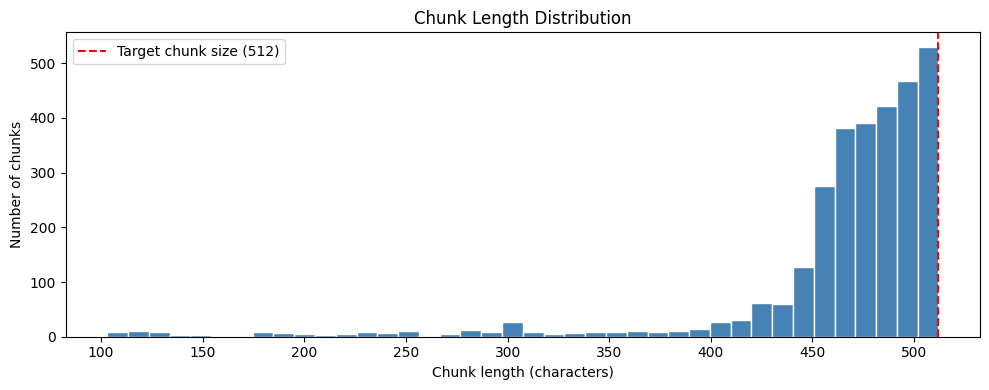

In [ ]:
chunk_lengths = [len(c.page_content) for c in chunks]

plt.figure(figsize=(10, 4))
plt.hist(chunk_lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'Target chunk size ({CHUNK_SIZE})')
plt.title('Chunk Length Distribution')
plt.xlabel('Chunk length (characters)')
plt.ylabel('Number of chunks')
plt.legend()
plt.tight_layout()
plt.savefig('../src/chunk_distribution.png', dpi=150)
plt.show()


In [14]:
# Build a summary DataFrame
rows = []
for chunk in chunks:
    source = os.path.basename(chunk.metadata.get('source', 'Unknown'))
    rows.append({'Source': source, 'Length': len(chunk.page_content)})

df = pd.DataFrame(rows)
summary = df.groupby('Source').agg(
    Chunk_Count=('Length', 'count'),
    Avg_Length=('Length', 'mean'),
    Min_Length=('Length', 'min'),
    Max_Length=('Length', 'max')
).round(0).astype(int)

print("📊 Chunk Statistics by Source Document\n")
print(summary.to_string())


📊 Chunk Statistics by Source Document

                                                                                   Chunk_Count  Avg_Length  Min_Length  Max_Length
Source                                                                                                                            
Increasing_Anaerobic_Endurance_Using_Strength_Endu.pdf                                      81         445         120         510
NSCA_1.pdf                                                                                 296         477         116         512
NSCA_2.pdf                                                                                 400         464         297         511
NSCA_3.pdf                                                                                 593         466         126         511
NSCA_4.pdf                                                                                 257         470         107         511
NSCA_5.pdf                                  

In [11]:
MIN_CHUNK_LENGTH = 100  # minimum characters to keep a chunk

original_count = len(chunks)
chunks = [c for c in chunks if len(c.page_content) >= MIN_CHUNK_LENGTH]
removed = original_count - len(chunks)

print(f"🗑️  Removed {removed} chunks below {MIN_CHUNK_LENGTH} chars")
print(f"✅ Final chunk count: {len(chunks)}")


🗑️  Removed 77 chunks below 100 chars
✅ Final chunk count: 2997


In [21]:
import pickle
import os

os.makedirs("../data/processed", exist_ok=True)
output_path = "../data/processed/chunks.pkl"

with open(output_path, "wb") as f:
    pickle.dump(chunks, f)

print(f"✅ Saved {len(chunks)} chunks to '{output_path}'")


✅ Saved 2997 chunks to '../data/processed/chunks.pkl'
